# Klasifikasi dengan ektraksi fitur menggunakan  Latent Dirichlet Allocation

## Library

In [1]:
!pip install -q nltk contractions emoji pyspellchecker Sastrawi

In [1]:
!pip install plotly
!pip install --upgrade gensim

In [2]:
import time
import re
import sys
import requests
import pandas as pd
from bs4 import BeautifulSoup
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import contractions
import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm
from spellchecker import SpellChecker
from collections import Counter
import numpy as np
from gensim.models import Word2Vec, FastText
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns

In [3]:
def print_progress(kategori, current_page, total_pages):
    percent = (current_page / total_pages) * 100
    bar_length = 20
    filled_length = int(bar_length * current_page // total_pages)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f'\r{kategori} - Page {current_page}/{total_pages} [{bar}] {percent:.2f}%')
    sys.stdout.flush()
    if current_page == total_pages:
        sys.stdout.write('\n\n')

In [4]:
# Fungsi untuk ambil konten artikel
def get_article_content(url):
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    soup = BeautifulSoup(r.text, "html.parser")

    paragraphs = []
    content_divs = soup.find_all("div", id="content-wrapper")
    for div in content_divs:
        for p in div.find_all("p"):
            text = p.get_text(strip=True)
            if text and not text.lower().startswith("baca juga"):
                paragraphs.append(text)
    return " ".join(paragraphs)

## Crawling Data Berita

In [5]:
categories = ["olahraga", "politik", "hukum", "ekonomi", "lingkungan", "internasional", "otomotif"]

In [6]:
def berita(categories, pages_per_category=1):
    start_time = time.time()  # mulai hitung waktu

    BASE_URL = "https://www.tempo.co/indeks?page={}&category=rubrik&rubric_slug={}"

    data = {
        "id_berita": [],
        "judul_berita": [],
        "isi_berita": [],
        "kategori_berita": []
    }

    for cat_id, cat in enumerate(categories, start=1):
        for page in range(1, pages_per_category+1):
            url = BASE_URL.format(page, cat)
            r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
            soup = BeautifulSoup(r.text, "html.parser")

            articles = soup.select("figure figcaption a")
            for a in articles:
                link = "https://www.tempo.co" + a["href"]
                title = a.get_text(strip=True)

                id_match = re.search(r"-(\d+)$", link)
                berita_id = id_match.group(1) if id_match else None

                try:
                    content = get_article_content(link)
                except:
                    content = ""

                data["id_berita"].append(berita_id)
                data["judul_berita"].append(title)
                data["isi_berita"].append(content)
                data["kategori_berita"].append(cat)

            print_progress(cat, page, pages_per_category)

    df = pd.DataFrame(data)
    df.to_csv("tempo_berita.csv", index=False, encoding="utf-8-sig")

    end_time = time.time()
    elapsed = int(end_time - start_time)
    jam, sisa = divmod(elapsed, 3600)
    menit, detik = divmod(sisa, 60)

    # summary
    print("\n✅ Seluruh data berhasil dikumpulkan!")
    print(f"📊 Total entri: {len(df)}")
    print(f"⏱️ Waktu eksekusi: {jam} jam {menit} menit {detik} detik")

    return None

In [7]:
berita(categories, pages_per_category=8)

olahraga - Page 8/8 [████████████████████] 100.00%

politik - Page 8/8 [████████████████████] 100.00%

hukum - Page 8/8 [████████████████████] 100.00%

ekonomi - Page 8/8 [████████████████████] 100.00%

lingkungan - Page 8/8 [████████████████████] 100.00%

internasional - Page 8/8 [████████████████████] 100.00%

otomotif - Page 8/8 [████████████████████] 100.00%


✅ Seluruh data berhasil dikumpulkan!
📊 Total entri: 1120
⏱️ Waktu eksekusi: 0 jam 22 menit 41 detik


In [8]:
berita_df = pd.read_csv("tempo_berita.csv")
berita_df

,id_berita,judul_berita,isi_berita,kategori_berita
0,2079642,Rekap Hasil Denmark Open 2025: 4 Wakil Indones...,EMPAT dari enam wakil Indonesia yang bertandin...,olahraga
1,2079319,WBA Perintahkan Duel Tinju Rolando Romero vs S...,WORLD Boxing Association (WBA) memerintahkan p...,olahraga
2,2079309,"Jadwal Kejuaraan Dunia Gimnastik 2025, Delapan...",FEDERASIGimnastikIndonesia mengumumkan delapan...,olahraga
3,2078880,Jadwal Timnas Argentina vs Puerto Rico pada Ra...,TIMNAS Argentinadijadwalkan bertanding melawan...,olahraga
4,2078763,"Timnas Indonesia Gagal ke Piala Dunia 2026, Ke...",KETUA Umum Persatuan Sepak Bola Seluruh Indone...,olahraga
...,...,...,...,...
1115,8259,"Bisa secara Offline maupun Online, Begini Cara...","TEMPO.CO,Jakarta- Pemblokiran Surat Tanda Nomo...",otomotif
1116,9220,Tips Merawat Motor Injeksi,"TEMPO.CO,Jakarta- Merawatmotorsebenarnya cukup...",otomotif
1117,17053,Tips Memanaskan Motor yang Benar agar Mesin Te...,"TEMPO.CO,Jakarta- Memanaskanmotorsebelum digun...",otomotif
1118,26264,"7 Mobil Teraman di Dunia, Dilengkapi dengan Te...","TEMPO.CO,Jakarta-Memilih mobil dengan fitur ke...",otomotif


## Pra-Premrosesan Data

In [9]:
# Download tokenizer
nltk.download("punkt")
nltk.download("punkt_tab")

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Pembersihan Teks

In [10]:
# Fungsi cleaning dengan emoji
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    text = text.lower()
    text = emoji.demojize(text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W', ' ', text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Baca file CSV
berita_df = pd.read_csv("tempo_berita.csv", dtype=str).fillna("")

# Terapkan fungsi cleaning ke kolom isi_berita
berita_df["isi_berita_clean"] = berita_df["isi_berita"].apply(clean_text)

In [11]:
berita_df[["isi_berita", "isi_berita_clean"]].head(5)

,isi_berita,isi_berita_clean
0,EMPAT dari enam wakil Indonesia yang bertandin...,empat dari enam wakil indonesia yang bertandin...
1,WORLD Boxing Association (WBA) memerintahkan p...,world boxing association wba memerintahkan per...
2,FEDERASIGimnastikIndonesia mengumumkan delapan...,federasigimnastik indonesia mengumumkan delapa...
3,TIMNAS Argentinadijadwalkan bertanding melawan...,timnas argentinadijadwalkan bertanding melawan...
4,KETUA Umum Persatuan Sepak Bola Seluruh Indone...,ketua umum persatuan sepak bola seluruh indone...


### Tokenisasi

In [12]:
# Tokenisasi untuk isi berita
berita_df["isi_berita_tokens"] = berita_df["isi_berita_clean"].apply(word_tokenize)

In [13]:
berita_df[["isi_berita_clean", "isi_berita_tokens"]].head(5)

,isi_berita_clean,isi_berita_tokens
0,empat dari enam wakil indonesia yang bertandin...,"[empat, dari, enam, wakil, indonesia, yang, be..."
1,world boxing association wba memerintahkan per...,"[world, boxing, association, wba, memerintahka..."
2,federasigimnastik indonesia mengumumkan delapa...,"[federasigimnastik, indonesia, mengumumkan, de..."
3,timnas argentinadijadwalkan bertanding melawan...,"[timnas, argentinadijadwalkan, bertanding, mel..."
4,ketua umum persatuan sepak bola seluruh indone...,"[ketua, umum, persatuan, sepak, bola, seluruh,..."


### Penghapusan Kata Umum (Stopwords)

In [14]:
# Stopwords untuk bahasa Indonesia
stop_words_id = set(stopwords.words('indonesian'))

# Filter stopwords di PTA
berita_df["isi_berita_filtered"] = berita_df["isi_berita_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words_id]
)

In [15]:
berita_df[["isi_berita_tokens", "isi_berita_filtered"]].head(5)

,isi_berita_tokens,isi_berita_filtered
0,"[empat, dari, enam, wakil, indonesia, yang, be...","[enam, wakil, indonesia, bertanding, turnamen,..."
1,"[world, boxing, association, wba, memerintahka...","[world, boxing, association, wba, memerintahka..."
2,"[federasigimnastik, indonesia, mengumumkan, de...","[federasigimnastik, indonesia, mengumumkan, de..."
3,"[timnas, argentinadijadwalkan, bertanding, mel...","[timnas, argentinadijadwalkan, bertanding, mel..."
4,"[ketua, umum, persatuan, sepak, bola, seluruh,...","[ketua, persatuan, sepak, bola, indonesia, pss..."


### Stemming

In [17]:
factory = StemmerFactory()
indo_stemmer = factory.create_stemmer()

berita_df["isi_berita_stemmed"] = berita_df["isi_berita_filtered"].apply(
    lambda tokens: [indo_stemmer.stem(word) for word in tokens]
)

In [18]:
berita_df[["isi_berita_filtered", "isi_berita_stemmed"]].head(5)

,isi_berita_filtered,isi_berita_stemmed
0,"[enam, wakil, indonesia, bertanding, turnamen,...","[enam, wakil, indonesia, tanding, turnamen, de..."
1,"[world, boxing, association, wba, memerintahka...","[world, boxing, association, wba, perintah, ta..."
2,"[federasigimnastik, indonesia, mengumumkan, de...","[federasigimnastik, indonesia, umum, delapan, ..."
3,"[timnas, argentinadijadwalkan, bertanding, mel...","[timnas, argentinadijadwalkan, tanding, lawan,..."
4,"[ketua, persatuan, sepak, bola, indonesia, pss...","[ketua, satu, sepak, bola, indonesia, pssi, er..."


### Ekspansi Kontraksi (Contraction Expansion / Normalisasi Kata)

In [19]:
# Fungsi expand kontraksi bahasa Indonesia
def expand_indonesian_contractions(text):
  contractions_dict = {
      # ======== Umum ========
      "gak": "tidak", "ga": "tidak", "nggak": "tidak", "enggak": "tidak", "ngga": "tidak",
      "gue": "saya", "gw": "saya", "gua": "saya", "lu": "kamu", "loe": "kamu",
      "udah": "sudah", "dah": "sudah", "blm": "belum", "tp": "tetapi", "trs": "terus",
      "yg": "yang", "utk": "untuk", "dr": "dari", "jd": "jadi", "krn": "karena",
      "dgn": "dengan", "sm": "sama", "thn": "tahun", "org": "orang",
      "tsb": "tersebut", "dll": "dan lain-lain", "dst": "dan seterusnya",
      "bgt": "sekali", "sgt": "sangat", "ok": "baik", "oke": "baik",
      "pls": "tolong", "plis": "tolong", "btw": "ngomong-ngomong",
      "wkwk": "tertawa", "hehe": "tertawa kecil", "cmiiw": "koreksi jika saya salah",

      # ======== POLITIK ========
      "pemilu": "pemilihan umum",
      "pilpres": "pemilihan presiden",
      "pileg": "pemilihan legislatif",
      "capres": "calon presiden",
      "cawapres": "calon wakil presiden",
      "cagub": "calon gubernur",
      "caleg": "calon legislatif",
      "parpol": "partai politik",
      "ketum": "ketua umum",
      "waketum": "wakil ketua umum",
      "bupati": "kepala daerah",
      "wapres": "wakil presiden",
      "menlu": "menteri luar negeri",
      "menkeu": "menteri keuangan",
      "menhan": "menteri pertahanan",
      "menhub": "menteri perhubungan",
      "menpora": "menteri pemuda dan olahraga",
      "menkumham": "menteri hukum dan hak asasi manusia",
      "kpk": "komisi pemberantasan korupsi",
      "dpr": "dewan perwakilan rakyat",
      "dpd": "dewan perwakilan daerah",
      "mk": "mahkamah konstitusi",
      "ma": "mahkamah agung",
      "pres": "presiden",
      "wapres": "wakil presiden",

      # ======== HUKUM ========
      "tersangka": "terduga pelaku",
      "tersidik": "terperiksa",
      "kejagung": "kejaksaan agung",
      "kejari": "kejaksaan negeri",
      "pn": "pengadilan negeri",
      "pt": "pengadilan tinggi",
      "pidana": "hukuman pidana",
      "perdata": "kasus perdata",
      "korup": "korupsi",
      "suap": "penyuapan",
      "gratifikasi": "pemberian ilegal",
      "vonis": "putusan pengadilan",
      "sidang": "persidangan",
      "tersangka": "terduga pelaku",
      "tersangka2": "terduga pelaku",

      # ======== EKONOMI ========
      "bi": "bank indonesia",
      "ojk": "otoritas jasa keuangan",
      "umkm": "usaha mikro kecil menengah",
      "bps": "badan pusat statistik",
      "bumn": "badan usaha milik negara",
      "inflasi": "kenaikan harga barang",
      "deflasi": "penurunan harga barang",
      "rupiah": "mata uang indonesia",
      "invest": "investasi",
      "investor": "penanam modal",
      "kurs": "nilai tukar",
      "saham": "kepemilikan perusahaan",
      "ekspor": "penjualan ke luar negeri",
      "impor": "pembelian dari luar negeri",

      # ======== LINGKUNGAN ========
      "bmkg": "badan meteorologi klimatologi dan geofisika",
      "bpbd": "badan penanggulangan bencana daerah",
      "bnpb": "badan nasional penanggulangan bencana",
      "plta": "pembangkit listrik tenaga air",
      "pltu": "pembangkit listrik tenaga uap",
      "plts": "pembangkit listrik tenaga surya",
      "emisi": "gas buang",
      "karhutla": "kebakaran hutan dan lahan",
      "banjir": "air meluap",
      "longsor": "tanah longsor",
      "sampah": "limbah",
      "hutan": "area pepohonan",
      "konservasi": "pelestarian alam",

      # ======== INTERNASIONAL ========
      "pbb": "perserikatan bangsa bangsa",
      "asean": "asosiasi negara negara asia tenggara",
      "who": "organisasi kesehatan dunia",
      "unicef": "badan anak anak pbb",
      "nato": "pakta pertahanan atlantik utara",
      "g20": "kelompok dua puluh negara",
      "imf": "international monetary fund",
      "fifa": "federasi sepak bola dunia",
      "uefa": "federasi sepak bola eropa",

      # ======== OTOMOTIF ========
      "bmw": "bayerische motoren werke",
      "avanza": "toyota avanza",
      "hrv": "honda hrv",
      "civic": "honda civic",
      "supra": "toyota supra",
      "cc": "kapasitas mesin",
      "rpm": "putaran per menit",
      "kopling": "sistem transmisi",
      "rem": "sistem pengereman",
      "ban": "roda kendaraan",
      "velg": "pelek roda",
      "mobil": "kendaraan roda empat",
      "motor": "kendaraan roda dua",
      "otomotif": "kendaraan bermotor",

      # ======== OLAHRAGA ========
      "fifa": "federasi sepak bola dunia",
      "uefa": "federasi sepak bola eropa",
      "afc": "konfederasi sepak bola asia",
      "bwf": "federasi bulu tangkis dunia",
      "nba": "liga bola basket amerika",
      "motogp": "grand prix sepeda motor",
      "formula1": "balap mobil formula satu",
      "pbsi": "persatuan bulu tangkis seluruh indonesia",
      "pssi": "persatuan sepak bola seluruh indonesia",
      "timnas": "tim nasional",
      "pelatih": "coach",
      "atlet": "olahragawan",
      "medali": "penghargaan olahraga",
  }



  pattern = r'\b(' + '|'.join(re.escape(key) for key in contractions_dict.keys()) + r')\b'

  def replace_match(match):
      return contractions_dict[match.group(0).lower()]

  expanded_text = re.sub(pattern, replace_match, text, flags=re.IGNORECASE)
  return expanded_text


berita_df["isi_berita_expanded"] = berita_df["isi_berita_stemmed"].apply(
    lambda tokens: expand_indonesian_contractions(" ".join(tokens)).split()
)

In [20]:
berita_df[["isi_berita_stemmed", "isi_berita_expanded"]].head(5)

,isi_berita_stemmed,isi_berita_expanded
0,"[enam, wakil, indonesia, tanding, turnamen, de...","[enam, wakil, indonesia, tanding, turnamen, de..."
1,"[world, boxing, association, wba, perintah, ta...","[world, boxing, association, wba, perintah, ta..."
2,"[federasigimnastik, indonesia, umum, delapan, ...","[federasigimnastik, indonesia, umum, delapan, ..."
3,"[timnas, argentinadijadwalkan, tanding, lawan,...","[tim, nasional, argentinadijadwalkan, tanding,..."
4,"[ketua, satu, sepak, bola, indonesia, pssi, er...","[ketua, satu, sepak, bola, indonesia, persatua..."


### Pemeriksaan Ejaan

In [21]:
# Inisialisasi SpellChecker kosong
spell = SpellChecker(language=None)

# Load kamus Indonesia dari file
with open("00-indonesian-wordlist.lst", "r", encoding="latin-1") as f:
    indo_words = [line.strip() for line in f.readlines()]

spell.word_frequency.load_words(indo_words)

# Fungsi untuk koreksi kata
def correct_word(word):
    corr = spell.correction(word)
    return corr if corr is not None else word

# Terapkan spellcheck ke setiap baris dengan progress bar
corrected_texts = []
for tokens in tqdm(berita_df["isi_berita_expanded"], desc="Spellchecking", unit="row"):
    corrected = [correct_word(word) for word in tokens]
    corrected_texts.append(corrected)

berita_df["isi_berita_spellchecked"] = corrected_texts

Spellchecking: 100%|██████████| 1120/1120 [3:17:33<00:00, 10.58s/row]


In [22]:
berita_df[["isi_berita_expanded", "isi_berita_spellchecked"]].head(5)

,isi_berita_expanded,isi_berita_spellchecked
0,"[enam, wakil, indonesia, tanding, turnamen, de...","[enam, wakil, indonesia, tanding, turnamen, de..."
1,"[world, boxing, association, wba, perintah, ta...","[bord, boling, association, aba, perintah, tar..."
2,"[federasigimnastik, indonesia, umum, delapan, ...","[federasigimnastik, indonesia, umum, delapan, ..."
3,"[tim, nasional, argentinadijadwalkan, tanding,...","[tim, nasional, argentinadijadwalkan, tanding,..."
4,"[ketua, satu, sepak, bola, indonesia, persatua...","[ketua, satu, sepak, bola, indonesia, persatua..."


### Analisis Frekuensi Kata

In [25]:
# Gabungkan semua token jadi satu list besar
all_tokens = [word for tokens in berita_df["isi_berita_spellchecked"] for word in tokens]

# Hitung frekuensi kata
word_freq = Counter(all_tokens)

# Ambil 20 kata paling sering muncul
common_words = word_freq.most_common(5)

print("=== 5 Kata Terbanyak ===")
for word, freq in common_words:
    print(f"{word} : {freq}")

# Informasi tambahan
total_words = len(all_tokens)                       # jumlah total kata
unique_words = len(word_freq)                       # jumlah kata unik
avg_words_per_data = np.mean([len(tokens) for tokens in berita_df["isi_berita_spellchecked"]])  # rata-rata jumlah kata per data

print("\n=== Statistik Tambahan ===")
print(f"Jumlah total kata       : {total_words}")
print(f"Jumlah kata unik        : {unique_words}")
print(f"Rata-rata kata per data : {avg_words_per_data:.2f} kata")

=== 5 Kata Terbanyak ===
oktober : 1675
indonesia : 1516
balap : 1417
menteri : 1294
pilih : 1155

=== Statistik Tambahan ===
Jumlah total kata       : 251064
Jumlah kata unik        : 15734
Rata-rata kata per data : 224.16 kata


In [27]:
# Ubah list token jadi string (gabungkan dengan spasi)
berita_df["isi_berita_hasil_praproses"] = berita_df["isi_berita_spellchecked"].apply(lambda x: " ".join(x))

# Simpan semua kolom ke CSV
berita_df.to_csv("berita_df_full.csv", index=False, encoding="utf-8-sig")

print("✅ File 'berita_df_full.csv' berhasil disimpan dengan semua kolom!")

✅ File 'berita_df_full.csv' berhasil disimpan dengan semua kolom!


In [4]:
berita_df = pd.read_csv("berita_df_full.csv")
berita_df

,id_berita,judul_berita,isi_berita,kategori_berita,isi_berita_clean,isi_berita_tokens,isi_berita_filtered,isi_berita_stemmed,isi_berita_expanded,isi_berita_spellchecked,isi_berita_hasil_praproses
0,2079642,Rekap Hasil Denmark Open 2025: 4 Wakil Indones...,EMPAT dari enam wakil Indonesia yang bertandin...,olahraga,empat dari enam wakil indonesia yang bertandin...,"['empat', 'dari', 'enam', 'wakil', 'indonesia'...","['enam', 'wakil', 'indonesia', 'bertanding', '...","['enam', 'wakil', 'indonesia', 'tanding', 'tur...","['enam', 'wakil', 'indonesia', 'tanding', 'tur...","['enam', 'wakil', 'indonesia', 'tanding', 'tur...",enam wakil indonesia tanding turnamen denmark ...
1,2079319,WBA Perintahkan Duel Tinju Rolando Romero vs S...,WORLD Boxing Association (WBA) memerintahkan p...,olahraga,world boxing association wba memerintahkan per...,"['world', 'boxing', 'association', 'wba', 'mem...","['world', 'boxing', 'association', 'wba', 'mem...","['world', 'boxing', 'association', 'wba', 'per...","['world', 'boxing', 'association', 'wba', 'per...","['bord', 'boling', 'association', 'aba', 'peri...",bord boling association aba perintah tarung wa...
2,2079309,"Jadwal Kejuaraan Dunia Gimnastik 2025, Delapan...",FEDERASIGimnastikIndonesia mengumumkan delapan...,olahraga,federasigimnastik indonesia mengumumkan delapa...,"['federasigimnastik', 'indonesia', 'mengumumka...","['federasigimnastik', 'indonesia', 'mengumumka...","['federasigimnastik', 'indonesia', 'umum', 'de...","['federasigimnastik', 'indonesia', 'umum', 'de...","['federasigimnastik', 'indonesia', 'umum', 'de...",federasigimnastik indonesia umum delapan olahr...
3,2078880,Jadwal Timnas Argentina vs Puerto Rico pada Ra...,TIMNAS Argentinadijadwalkan bertanding melawan...,olahraga,timnas argentinadijadwalkan bertanding melawan...,"['timnas', 'argentinadijadwalkan', 'bertanding...","['timnas', 'argentinadijadwalkan', 'bertanding...","['timnas', 'argentinadijadwalkan', 'tanding', ...","['tim', 'nasional', 'argentinadijadwalkan', 't...","['tim', 'nasional', 'argentinadijadwalkan', 't...",tim nasional argentinadijadwalkan tanding lawa...
4,2078763,"Timnas Indonesia Gagal ke Piala Dunia 2026, Ke...",KETUA Umum Persatuan Sepak Bola Seluruh Indone...,olahraga,ketua umum persatuan sepak bola seluruh indone...,"['ketua', 'umum', 'persatuan', 'sepak', 'bola'...","['ketua', 'persatuan', 'sepak', 'bola', 'indon...","['ketua', 'satu', 'sepak', 'bola', 'indonesia'...","['ketua', 'satu', 'sepak', 'bola', 'indonesia'...","['ketua', 'satu', 'sepak', 'bola', 'indonesia'...",ketua satu sepak bola indonesia persatuan sepa...
...,...,...,...,...,...,...,...,...,...,...,...
1115,8259,"Bisa secara Offline maupun Online, Begini Cara...","TEMPO.CO,Jakarta- Pemblokiran Surat Tanda Nomo...",otomotif,tempocojakarta pemblokiran surat tanda nomor k...,"['tempocojakarta', 'pemblokiran', 'surat', 'ta...","['tempocojakarta', 'pemblokiran', 'surat', 'ta...","['tempocojakarta', 'blokir', 'surat', 'tanda',...","['tempocojakarta', 'blokir', 'surat', 'tanda',...","['tempocojakarta', 'blokir', 'surat', 'tanda',...",tempocojakarta blokir surat tanda nomor kendar...
1116,9220,Tips Merawat Motor Injeksi,"TEMPO.CO,Jakarta- Merawatmotorsebenarnya cukup...",otomotif,tempocojakarta merawatmotorsebenarnya cukup mu...,"['tempocojakarta', 'merawatmotorsebenarnya', '...","['tempocojakarta', 'merawatmotorsebenarnya', '...","['tempocojakarta', 'merawatmotorsebenarnya', '...","['tempocojakarta', 'merawatmotorsebenarnya', '...","['tempocojakarta', 'merawatmotorsebenarnya', '...",tempocojakarta merawatmotorsebenarnya mudah ka...
1117,17053,Tips Memanaskan Motor yang Benar agar Mesin Te...,"TEMPO.CO,Jakarta- Memanaskanmotorsebelum digun...",otomotif,tempocojakarta memanaskanmotorsebelum digunaka...,"['tempocojakarta', 'memanaskanmotorsebelum', '...","['tempocojakarta', 'memanaskanmotorsebelum', '...","['tempocojakarta', 'memanaskanmotorsebelum', '...","['tempocojakarta', 'memanaskanmotorsebelum', '...","['tempocojakarta', 'memanaskanmotor

In [28]:
# Simpan semua kata + frekuensi ke CSV
word_freq_df = pd.DataFrame(word_freq.items(), columns=["kata", "jumlah"])
word_freq_df = word_freq_df.sort_values(by="jumlah", ascending=False).reset_index(drop=True)
word_freq_df.to_csv("berita_word_frequency.csv", index=False, encoding="utf-8-sig")

print("\n✅ File berhasil disimpan sebagai berita_word_frequency.csv.")


✅ File berhasil disimpan sebagai berita_word_frequency.csv.


In [32]:
berita_freq_df = pd.read_csv("berita_word_frequency.csv")
berita_freq_df.head(5)

,kata,jumlah
0,oktober,1675
1,indonesia,1516
2,balap,1417
3,menteri,1294
4,pilih,1155


## TF-IDF

In [5]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(berita_df['isi_berita_hasil_praproses'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [6]:
print("\nTF-IDF shape:", tfidf_df.shape)
tfidf_df


TF-IDF shape: (1120, 15675)


,aa,ab,aba,abad,abadi,abadijaya,abai,abak,abaka,abal,...,zulaikha,zulfikar,zulkarnain,zulkifli,zulverdi,zuriah,zuriat,zverev,zwiers,zyrexindo
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.417185,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1116,0.0,0.0,0.000000,0.0,0.0,0.0,0.021815,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1117,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1118,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Word Embeding

In [7]:
corpus = []
for col in berita_df['isi_berita_hasil_praproses']:
   word_list = col.split(" ")
   corpus.append(word_list)

#show first value
corpus[0:1]

#generate vectors from corpus
model = Word2Vec(corpus, min_count=1, vector_size = 56)

In [12]:
# explore embeddings using cosine similarity
print("Kata mirip dengan 'politik':")
print(model.wv.most_similar('politik', topn=5))

print("\nKata mirip dengan 'ekonomi':")
print(model.wv.most_similar('ekonomi', topn=5))

# contoh cosmul
print("\nCosmul (olahraga + pemain - cedera):")
print(model.wv.most_similar_cosmul(positive=['olahraga', 'pemain'], negative=['cedera'], topn=5))

# save embeddings
filename = 'berita_embeddings.txt'
model.wv.save_word2vec_format(filename, binary=False)
print(f"\n✅ Embeddings disimpan ke {filename}")

Kata mirip dengan 'politik':
[('beliau', 0.9907154440879822), ('kritik', 0.9889357089996338), ('komite', 0.9877463579177856), ('bina', 0.9877426028251648), ('amanat', 0.9870116710662842)]

Kata mirip dengan 'ekonomi':
[('biaya', 0.981437623500824), ('butuh', 0.9734936952590942), ('pagu', 0.9704659581184387), ('dorong', 0.9702861309051514), ('miskin', 0.9661499857902527)]

Cosmul (olahraga + pemain - cedera):
[('pemuda', 1.1375715732574463), ('menteri', 1.133134365081787), ('kemenpora', 1.125199317932129), ('erik', 1.1116164922714233), ('jabat', 1.1097577810287476)]

✅ Embeddings disimpan ke berita_embeddings.txt


In [13]:
class MyTokenizer:
    def fit_transform(self, texts):
        # Tokenisasi sederhana: lowercase + split
        return [str(text).lower().split() for text in texts]

class MeanEmbeddingVectorizer:
    def __init__(self, word2vec_model):
        self.word2vec = word2vec_model
        # Perbaikan: gunakan vector_size (Gensim ≥ 4.0)
        self.dim = word2vec_model.wv.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_tokenized = MyTokenizer().fit_transform(X)
        embeddings = []
        for words in X_tokenized:
            # Ambil vektor hanya untuk kata yang ada di vocab
            valid_vectors = [
                self.word2vec.wv[word] for word in words
                if word in self.word2vec.wv
            ]
            if valid_vectors:
                embeddings.append(np.mean(valid_vectors, axis=0))
            else:
                embeddings.append(np.zeros(self.dim))
        return np.array(embeddings)

    def fit_transform(self, X, y=None):
        return self.transform(X)

In [14]:
berita_df.shape

(1120, 11)

In [16]:
mean_embedding_vectorizer = MeanEmbeddingVectorizer(model)
mean_embedded = mean_embedding_vectorizer.fit_transform(berita_df['isi_berita_hasil_praproses'])

In [17]:
berita_df['array']=list(mean_embedded)

In [21]:
berita_df[["isi_berita_hasil_praproses", "array"]].head(10)

,isi_berita_hasil_praproses,array
0,enam wakil indonesia tanding turnamen denmark ...,"[-0.243297, -0.5428428, 0.5578849, -0.23852375..."
1,bord boling association aba perintah tarung wa...,"[-0.22314793, -0.4578888, 0.5378914, -0.213452..."
2,federasigimnastik indonesia umum delapan olahr...,"[-0.08688285, -0.5151892, 0.3655661, -0.145513..."
3,tim nasional argentinadijadwalkan tanding lawa...,"[-0.1546983, -0.4516442, 0.48055208, -0.187988..."
4,ketua satu sepak bola indonesia persatuan sepa...,"[-0.19174963, -0.68079686, 0.5345737, -0.23575..."
5,tim bulu tangkis junior indonesia gagal tahan ...,"[-0.21266754, -0.5296142, 0.5155856, -0.285040..."
6,komite olimpiade indonesia koi terima kunjung ...,"[-0.11012901, -0.6412247, 0.39660716, -0.14086..."
7,latih tim nasional u indonesiaindra ajari tena...,"[-0.11406921, -0.5905765, 0.51901805, -0.16370..."
8,juara dunia moto ap mac marquez absen gand pri...,"[-0.19394013, -0.43182826, 0.7141681, -0.58685..."
9,tim bulu tangkis indonesia duel lawan cina fin...,"[-0.23541167, -0.6102881, 0.6171878, -0.255328..."


In [22]:
berita_df['embedding_length'] = berita_df['array'].str.len()

In [23]:
print(berita_df['embedding_length'])

0       56
1       56
2       56
3       56
4       56
        ..
1115    56
1116    56
1117    56
1118    56
1119    56
Name: embedding_length, Length: 1120, dtype: int64


In [24]:
berita_df.shape

(1120, 13)

In [25]:
num_features = len(berita_df['array'].iloc[0])  # asumsi semua list punya panjang sama
columns = [f'f{i+1}' for i in range(num_features)]

# Inisialisasi dictionary untuk menampung data per kolom
data_dict = {col: [] for col in columns}

# Looping setiap baris di kolom 'embedding'
for embedding_list in berita_df['array']:
    for i, value in enumerate(embedding_list):
        data_dict[f'f{i+1}'].append(value)

# Buat DataFrame dari dictionary
embedding_df = pd.DataFrame(data_dict)

In [26]:
embedding_df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56
0,-0.243297,-0.542843,0.557885,-0.238524,-0.572785,-0.225307,0.249917,-0.535898,0.074426,0.045858,...,0.566034,0.390283,-0.262411,0.153634,-0.526807,-0.048610,0.416923,0.123373,0.458920,0.233683
1,-0.223148,-0.457889,0.537891,-0.213453,-0.666882,-0.076854,0.254644,-0.586271,0.031237,-0.036102,...,0.637451,0.451151,-0.334427,0.113041,-0.557241,-0.081254,0.414048,0.120573,0.378601,0.313634
2,-0.086883,-0.515189,0.365566,-0.145513,-0.539763,-0.088451,0.203449,-0.539588,-0.042574,-0.151580,...,0.508457,0.299115,-0.226501,0.136495,-0.407302,0.001033,0.346872,0.232844,0.281393,0.131196
3,-0.154698,-0.451644,0.480552,-0.187988,-0.491874,-0.180410,0.217029,-0.525400,0.052440,-0.025356,...,0.463331,0.340835,-0.275655,0.136144,-0.426233,-0.034727,0.267650,0.101347,0.372135,0.212491
4,-0.191750,-0.680797,0.534574,-0.235758,-0.670560,-0.251022,0.243525,-0.685272,-0.019848,-0.095811,...,0.658227,0.410541,-0.310374,0.238341,-0.537648,-0.089237,0.372175,0.281935,0.442479,0.267667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,0.035866,-0.392298,0.408169,-0.142092,-0.448322,-0.253270,0.377572,-0.717332,0.026736,-0.223090,...,0.375227,0.241031,-0.258723,0.171719,-0.422428,0.354101,0.367043,0.169888,0.295053,-0.104062
1116,0.303128,-0.179903,0.369610,-0.509178,-0.428036,-0.595070,0.566230,-0.663726,0.442571,-0.274586,...,0.139853,0.102912,-0.578146,0.415760,-0.376905,0.691667,0.729165,0.036730,0.376515,-0.142876
1117,0.664310,0.087615,0.307080,-0.891263,-0.402938,-1.225650,0.893710,-0.762068,0.876055,-0.452432,...,-0.076751,-0.019821,-0.942798,0.681333,-0.315581,1.313833,0.989275,0.011606,0.496965,-0.252284
1118,0.327906,-0.086265,0.300504,-0.654394,-0.448575,-0.701323,0.588513,-0.591427,0.517664,-0.274097,...,0.198294,0.095159,-0.667873,0.454679,-0.335334,0.690591,0.726812,0.050852,0.426671,-0.023940


In [27]:
embedding_df.shape

(1120, 56)

## Klasifikasi LDA

In [33]:
if 'isi_berita_tokens_hasil' not in berita_df.columns:
    berita_df['isi_berita_tokens_hasil'] = berita_df['isi_berita_hasil_praproses'].apply(lambda x: str(x).split())

# Dataset teks tokenized
texts = berita_df['isi_berita_tokens_hasil']

In [34]:
# Buat dictionary dan corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

🚀 Memulai evaluasi jumlah topik...



Training LDA untuk berbagai jumlah topik: 100%|██████████| 13/13 [18:28<00:00, 85.30s/model] 



✅ Evaluasi selesai!


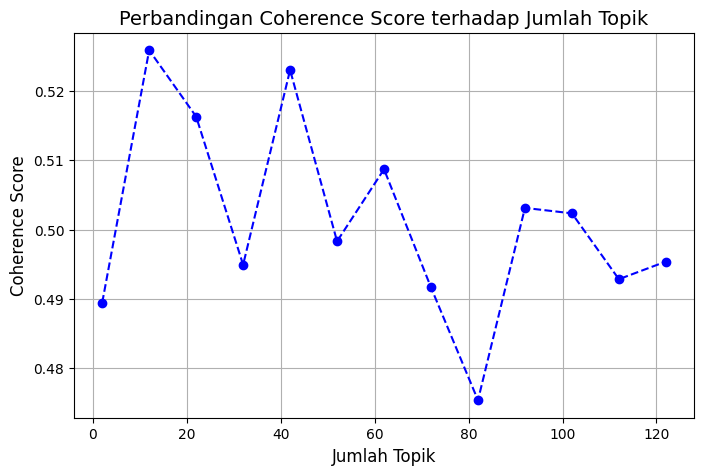

🏆 Model terbaik memiliki 12 topik
📈 Coherence Score terbaik: 0.5259


In [36]:
# === Evaluasi jumlah topik optimal ===
coherence_values = []
model_list = []
topic_range = range(2, 130, 10)

print("🚀 Memulai evaluasi jumlah topik...\n")

# tqdm untuk progress bar
for num_topics in tqdm(topic_range, desc="Training LDA untuk berbagai jumlah topik", unit="model"):
    model = LdaModel(
        corpus=corpus,
        num_topics=num_topics,
        id2word=dictionary,
        random_state=42,
        passes=10,
        iterations=100
    )
    model_list.append(model)

    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

print("\n✅ Evaluasi selesai!")

# === Visualisasi Coherence Score ===
plt.figure(figsize=(8, 5))
plt.plot(topic_range, coherence_values, marker='o', linestyle='--', color='b')
plt.xlabel("Jumlah Topik", fontsize=12)
plt.ylabel("Coherence Score", fontsize=12)
plt.title("Perbandingan Coherence Score terhadap Jumlah Topik", fontsize=14)
plt.grid(True)
plt.show()

# === Model terbaik ===
optimal_model = model_list[coherence_values.index(max(coherence_values))]
optimal_topics = topic_range[coherence_values.index(max(coherence_values))]

print("🏆 Model terbaik memiliki", optimal_topics, "topik")
print("📈 Coherence Score terbaik:", round(max(coherence_values), 4))

In [37]:
for idx, topic in optimal_model.print_topics(-1):
    print(f"\nTopik {idx+1}: {topic}")


Topik 1: 0.011*"indonesia" + 0.011*"kendaraan" + 0.010*"rp" + 0.010*"roda" + 0.007*"persen" + 0.006*"oktober" + 0.005*"pilih" + 0.005*"milik" + 0.005*"dua" + 0.004*"usaha"

Topik 2: 0.007*"cedera" + 0.006*"roda" + 0.006*"jalan" + 0.006*"kendaraan" + 0.005*"bandara" + 0.005*"milik" + 0.005*"empat" + 0.004*"dunia" + 0.004*"balap" + 0.004*"goodall"

Topik 3: 0.041*"balap" + 0.027*"marquez" + 0.024*"ap" + 0.020*"moto" + 0.017*"posisi" + 0.015*"poin" + 0.014*"mac" + 0.012*"ale" + 0.011*"juara" + 0.010*"menang"

Topik 4: 0.012*"rakyat" + 0.012*"dewan" + 0.010*"dana" + 0.010*"oktober" + 0.010*"menteri" + 0.009*"perwakilan" + 0.008*"presiden" + 0.008*"rp" + 0.007*"perintah" + 0.007*"kepala"

Topik 5: 0.011*"indonesia" + 0.010*"area" + 0.009*"pepohonan" + 0.008*"menteri" + 0.007*"tanah" + 0.006*"jakarta" + 0.006*"bola" + 0.006*"nasional" + 0.006*"sepak" + 0.006*"dunia"

Topik 6: 0.025*"balap" + 0.013*"ap" + 0.011*"posisi" + 0.011*"detik" + 0.011*"moto" + 0.009*"mandalika" + 0.008*"indonesia" +

In [38]:
dominant_topics = []

for i, doc_bow in enumerate(corpus):
    topics_in_doc = optimal_model.get_document_topics(doc_bow, minimum_probability=0)
    topics_in_doc = sorted(topics_in_doc, key=lambda x: x[1], reverse=True)
    topic_num, prop = topics_in_doc[0]
    dominant_topics.append((topic_num + 1, round(prop, 3)))

df_dominant = pd.DataFrame(dominant_topics, columns=["Topik Dominan", "Proporsi"])

df_result = pd.concat([berita_df.reset_index(drop=True), df_dominant.reset_index(drop=True)], axis=1)

display(df_result[["judul_berita", "kategori_berita", "Topik Dominan", "Proporsi", "isi_berita_hasil_praproses"]])

,judul_berita,kategori_berita,Topik Dominan,Proporsi,isi_berita_hasil_praproses
0,Rekap Hasil Denmark Open 2025: 4 Wakil Indones...,olahraga,7,0.997,enam wakil indonesia tanding turnamen denmark ...
1,WBA Perintahkan Duel Tinju Rolando Romero vs S...,olahraga,5,0.620,bord boling association aba perintah tarung wa...
2,"Jadwal Kejuaraan Dunia Gimnastik 2025, Delapan...",olahraga,5,0.995,federasigimnastik indonesia umum delapan olahr...
3,Jadwal Timnas Argentina vs Puerto Rico pada Ra...,olahraga,12,0.323,tim nasional argentinadijadwalkan tanding lawa...
4,"Timnas Indonesia Gagal ke Piala Dunia 2026, Ke...",olahraga,5,0.685,ketua satu sepak bola indonesia persatuan sepa...
...,...,...,...,...,...
1115,"Bisa secara Offline maupun Online, Begini Cara...",otomotif,2,0.707,tempocojakarta blokir surat tanda nomor kendar...
1116,Tips Merawat Motor Injeksi,otomotif,1,0.997,tempocojakarta merawatmotorsebenarnya mudah ka...
1117,Tips Memanaskan Motor yang Benar agar Mesin Te...,otomotif,1,0.687,tempocojakarta memanaskanmotorsebelum langkah ...
1118,"7 Mobil Teraman di Dunia, Dilengkapi dengan Te...",otomotif,2,0.997,tempocojakartamemilih kendaraan roda empat fit...


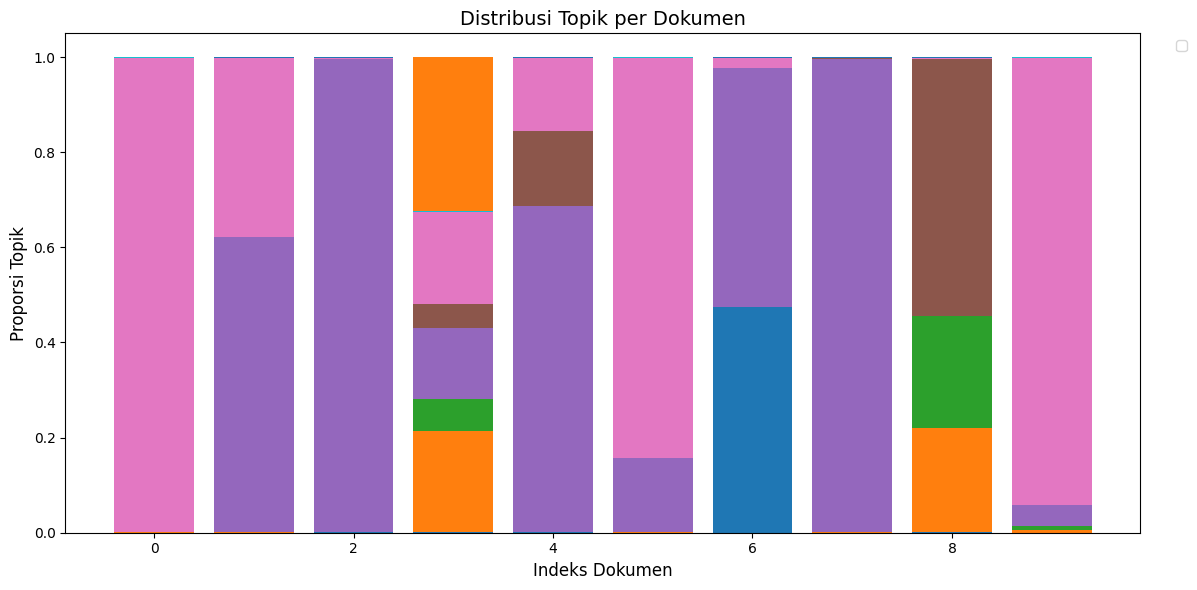

In [39]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]
n_docs = min(10, len(topic_distribution))
data = np.array([[prob for _, prob in topic_distribution[i]] for i in range(n_docs)])

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(n_docs)

for k in range(data.shape[1]):
    ax.bar(range(n_docs), data[:, k], bottom=bottom)
    bottom += data[:, k]

# Judul dan label sumbu
ax.set_title("Distribusi Topik per Dokumen", fontsize=14)
ax.set_xlabel("Indeks Dokumen", fontsize=12)
ax.set_ylabel("Proporsi Topik", fontsize=12)

ax.legend(bbox_to_anchor=(1.05, 1),)
plt.tight_layout()
plt.show()


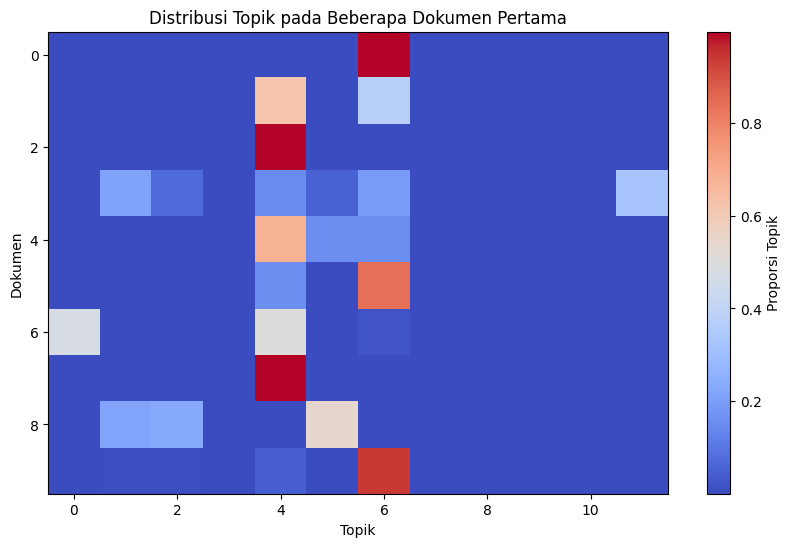

In [40]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

num_docs_to_show = 10
topic_matrix = np.array([[score for _, score in doc] for doc in topic_distribution[:num_docs_to_show]])

plt.figure(figsize=(10, 6))
plt.imshow(topic_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Proporsi Topik')
plt.xlabel('Topik')
plt.ylabel('Dokumen')
plt.title('Distribusi Topik pada Beberapa Dokumen Pertama')
plt.show()

In [41]:
X = df_result["isi_berita_hasil_praproses"].astype(str)  # teks input
y = df_result["kategori_berita"].astype(str)   # label kategori

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


In [42]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Softmax Regression
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax_model.fit(X_train, y_train)
y_pred_softmax = softmax_model.predict(X_test)

In [43]:
def evaluasi_model(y_true, y_pred, model_name):
    print(f"\n=== Evaluasi Model: {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

🔍 Evaluasi Model SVM

=== Evaluasi Model: SVM ===
Accuracy : 0.9017857142857143
Precision: 0.9106200659405899
Recall   : 0.9017857142857143

Classification Report:
                precision    recall  f1-score   support

      ekonomi       0.76      0.97      0.85        32
        hukum       1.00      0.91      0.95        32
internasional       0.97      0.97      0.97        32
   lingkungan       1.00      0.91      0.95        32
     olahraga       0.85      0.91      0.88        32
     otomotif       0.90      0.81      0.85        32
      politik       0.90      0.84      0.87        32

     accuracy                           0.90       224
    macro avg       0.91      0.90      0.90       224
 weighted avg       0.91      0.90      0.90       224



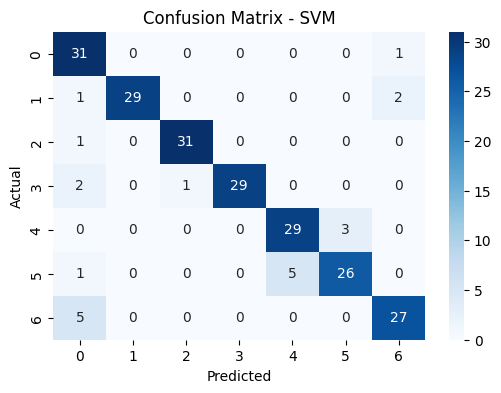

In [44]:
print("🔍 Evaluasi Model SVM")
evaluasi_model(y_test, y_pred_svm, "SVM")



🔍 Evaluasi Model Softmax Regression

=== Evaluasi Model: Softmax Regression ===
Accuracy : 0.8928571428571429
Precision: 0.8989823348694318
Recall   : 0.8928571428571429

Classification Report:
                precision    recall  f1-score   support

      ekonomi       0.78      0.97      0.86        32
        hukum       0.97      0.91      0.94        32
internasional       0.97      0.97      0.97        32
   lingkungan       1.00      0.91      0.95        32
     olahraga       0.84      0.84      0.84        32
     otomotif       0.84      0.81      0.83        32
      politik       0.90      0.84      0.87        32

     accuracy                           0.89       224
    macro avg       0.90      0.89      0.89       224
 weighted avg       0.90      0.89      0.89       224



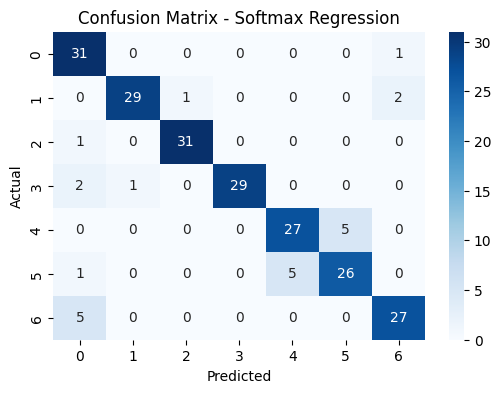

In [45]:
print("\n\n🔍 Evaluasi Model Softmax Regression")
evaluasi_model(y_test, y_pred_softmax, "Softmax Regression")

In [46]:
coherence_model = CoherenceModel(model=optimal_model, texts=texts, dictionary=dictionary, coherence='c_v')
coherence = coherence_model.get_coherence()
print("Coherence Score (c_v) untuk model terbaik:", coherence)

Coherence Score (c_v) untuk model terbaik: 0.5258841668416897
